# Human Activity Recognition (HAR) using Time Series Sensor Data

This notebook focuses on building a Human Activity Recognition (HAR) system using time series data collected from sensors. The goal is to classify different human activities (e.g., walking, standing, sitting) based on patterns observed in sensor readings over time. This involves loading the dataset, understanding its structure, visualizing sensor data, and eventually building a classification model.

In [ ]:
import numpy as np

project_data = np.load("/content/project_data.npz", allow_pickle=True)

X_train = project_data['X_train']
y_train = project_data['y_train']
X_test = project_data['X_test']
y_test = project_data['y_test']

### 1. Data Loading and Initial Inspection

We start by loading the preprocessed sensor data, which is stored in a `.npz` file. This file contains the training and testing sets for both features (X) and labels (y).

In [ ]:
print(project_data)

NpzFile '/content/project_data.npz' with keys: X_train, y_train, X_test, y_test


Let's inspect the keys available in the loaded `.npz` file to understand the structure of our dataset.

In [ ]:
print(X_train.shape, y_train.shape)

(40500, 55, 8) (40500,)


### 2. Understanding Data Shapes

It's crucial to understand the dimensions of our training and test datasets. The sensor data is typically 3-dimensional, representing `(number_of_samples, timesteps, number_of_features)`.

In [ ]:
[X_test.shape, y_test.shape]

[(4500, 55, 8), (4500,)]

In [ ]:
print(X_train[0].shape)

(55, 8)


Let's examine the shape of a single sample (X_train[0]) to confirm the number of timesteps and features per sample, and the corresponding label (y_train[0]) which represents the activity class.

In [ ]:
print(y_train[0].shape)

()


In [ ]:
print(y_train[0])

8


In [ ]:
print(X_train[1].shape)

(55, 8)


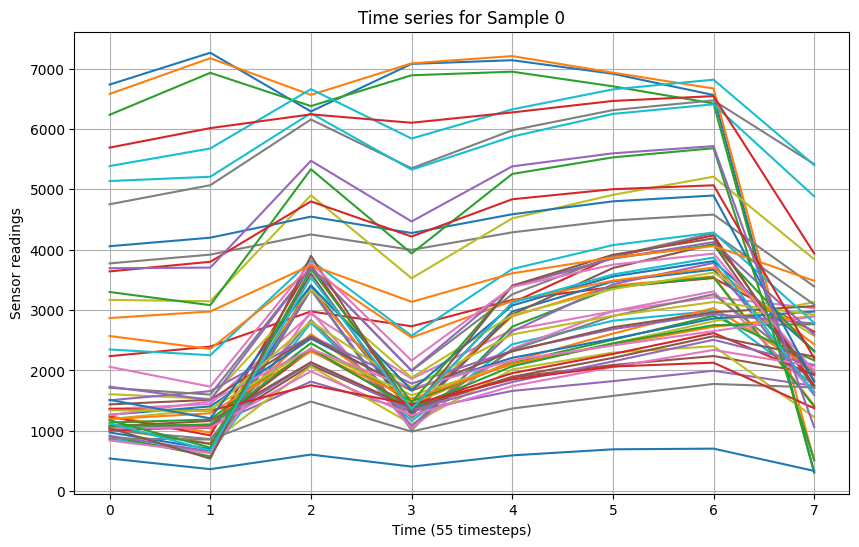

In [ ]:
import matplotlib.pyplot as plt

def plot_sample(X, index=0):
    plt.figure(figsize=(10, 6))
    for i in range(55):
        plt.plot(X[index, i, :], label=f"Sensor {i+1}")
    plt.title(f"Time series for Sample {index}")
    plt.xlabel("Time (55 timesteps)")
    plt.ylabel("Sensor readings")
    plt.grid(True)
    plt.show()

plot_sample(X_train, index=0)


### 3. Visualizing Sensor Data

Visualizing raw sensor data is an important step to gain insights into the patterns associated with different activities. Here, we define a function to plot a single sample's time series. The initial attempt below intended to plot 55 separate time series, misinterpreting the sensor data dimensions.


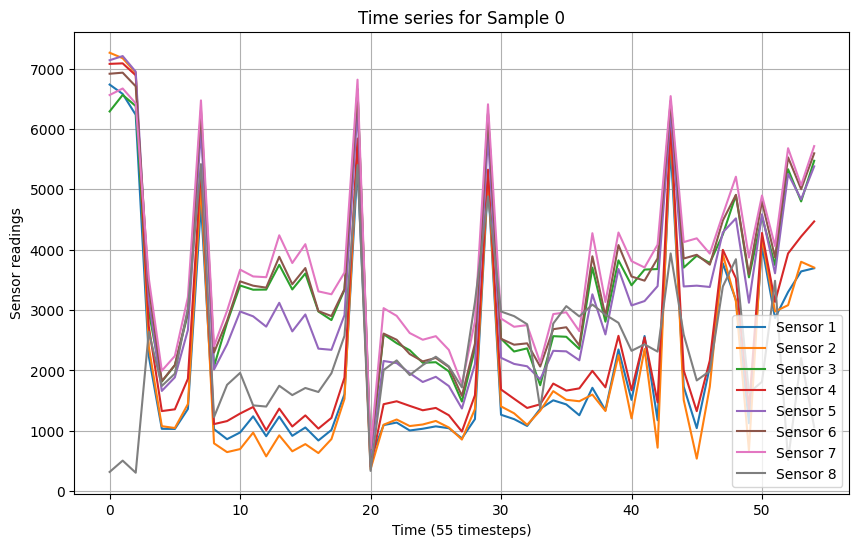

In [ ]:
import matplotlib.pyplot as plt

def plot_sample(X, index=0):
    plt.figure(figsize=(10, 6))
    for i in range(8):
        plt.plot(X[index, :, i], label=f"Sensor {i+1}")
    plt.title(f"Time series for Sample {index}")
    plt.xlabel("Time (55 timesteps)")
    plt.ylabel("Sensor readings")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sample(X_train, index=0)


This corrected version of the `plot_sample` function properly visualizes the 8 sensor features (channels) over 55 timesteps for a given sample, allowing us to see how each sensor reading changes over time for a specific activity instance.

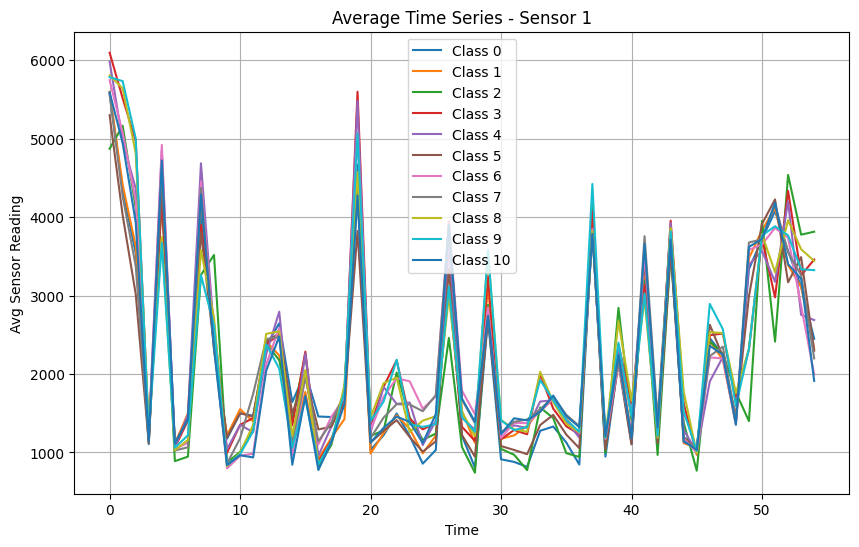

In [ ]:
import numpy as np

def plot_avg_per_class(X, y, sensor_id=0):
    plt.figure(figsize=(10, 6))
    for cls in np.unique(y):
        avg_signal = X[y == cls, :, sensor_id].mean(axis=0)
        plt.plot(avg_signal, label=f"Class {cls}")
    plt.title(f"Average Time Series - Sensor {sensor_id + 1}")
    plt.xlabel("Time")
    plt.ylabel("Avg Sensor Reading")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_avg_per_class(X_train, y_train, sensor_id=0)


### 4. Exploring Class-wise Average Sensor Readings

To understand the distinguishing characteristics of each activity class, we can visualize the average time series for each sensor across all samples belonging to a particular class. This helps in identifying potential features that differentiate one activity from another.